In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

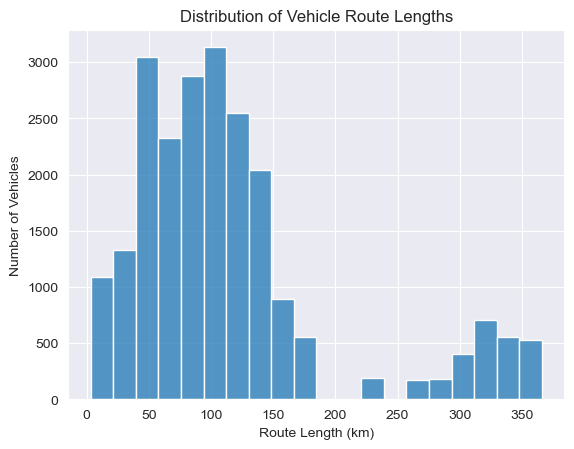

In [8]:
df_routes = pd.read_csv('scenario0_routes.csv')
sns.histplot(df_routes['route_length_km'], bins=20)
plt.xlabel("Route Length (km)")
plt.ylabel("Number of Vehicles")
plt.title("Distribution of Vehicle Route Lengths")
plt.show()

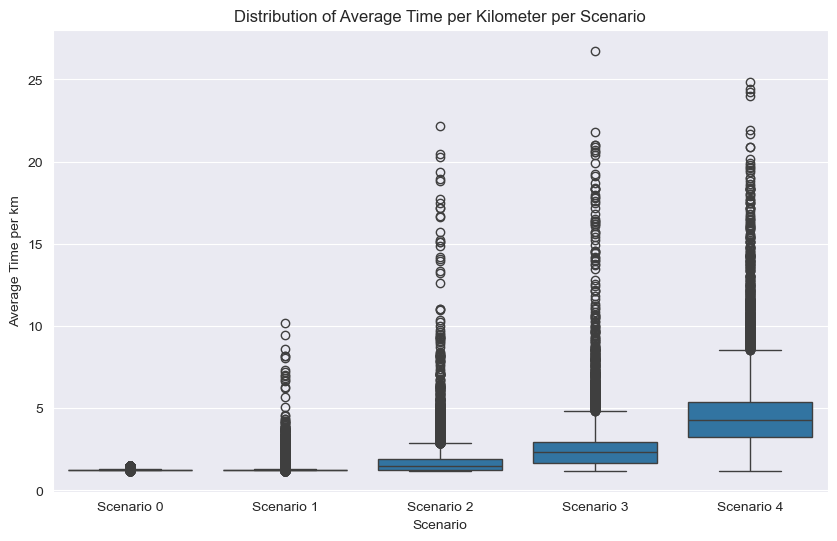

In [9]:
# List of your CSV files for each scenario
files = [
    "scenario0_routes.csv",
    "scenario1_routes.csv",
    "scenario2_routes.csv",
    "scenario3_routes.csv",
    "scenario4_routes.csv"
]

# Combine all scenarios into one DataFrame
dfs = []
for i, f in enumerate(files):
    df = pd.read_csv(f)
    df['scenario'] = f"Scenario {i}"
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Calculate time per kilometer
df_all['time_per_km'] = df_all['driving_time_min'] / df_all['route_length_km']  # adjust column names if needed

# Plot boxplot with average overlay
plt.figure(figsize=(10, 6))
sns.boxplot(x='scenario', y='time_per_km', data=df_all)
#sns.pointplot(x='scenario', y='time_per_km', data=df_all, color='red', estimator='mean', ci=None)
plt.xlabel("Scenario")
plt.ylabel("Average Time per km")
plt.title("Distribution of Average Time per Kilometer per Scenario")
plt.show()

Loaded 110870 rows from 5 file(s)
scenario
0    22565
1    22544
2    22395
3    22093
4    21273
Name: count, dtype: int64


C:\Users\lukav\AppData\Local\Temp\ipykernel_37176\1879508422.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


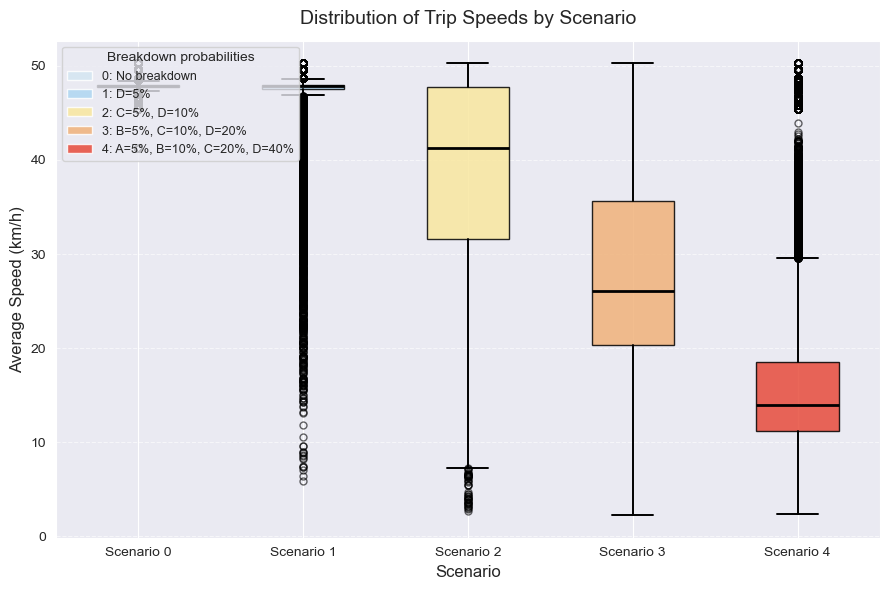

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

files = sorted(glob.glob("scenario*_routes.csv"))

if not files:
    raise FileNotFoundError("No scenario*_routes.csv files found in experiment/")

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print(f"Loaded {len(data)} rows from {len(files)} file(s)")
print(data["scenario"].value_counts().sort_index())

# ── Compute speed (km/h) per trip: route_length_km / (driving_time_min / 60) ──
data["speed_kmh"] = data["route_length_km"] / (data["driving_time_min"] / 60)

# ── Build per-trip speed distribution per scenario ───────────────────────────
scenarios = sorted(data["scenario"].unique())
box_data  = [data[data["scenario"] == s]["speed_kmh"].values for s in scenarios]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

bp = ax.boxplot(
    box_data,
    labels=[f"Scenario {s}" for s in scenarios],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    flierprops=dict(marker="o", markersize=5, linestyle="none", alpha=0.6),
)

# Colour boxes by scenario severity (light → dark red)
colors = ["#d4e6f1", "#aed6f1", "#f9e79f", "#f0b27a", "#e74c3c"]
for patch, color in zip(bp["boxes"], colors[:len(scenarios)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_title("Distribution of Trip Speeds by Scenario", fontsize=14, pad=12)
ax.set_xlabel("Scenario", fontsize=12)
ax.set_ylabel("Average Speed (km/h)", fontsize=12)
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

scenario_labels = [
    "0: No breakdown",
    "1: D=5%",
    "2: C=5%, D=10%",
    "3: B=5%, C=10%, D=20%",
    "4: A=5%, B=10%, C=20%, D=40%",
]
legend_handles = [
    plt.Rectangle((0,0), 1, 1, fc=colors[i], alpha=0.85)
    for i in range(len(scenarios))
]
ax.legend(legend_handles, scenario_labels[:len(scenarios)],
          title="Breakdown probabilities", loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

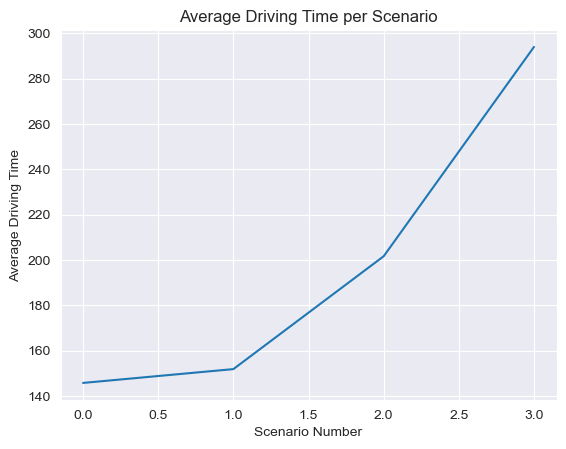

In [10]:
files = {}
for i in range(0, 4):
    files[i] = pd.read_csv(f'scenario{i}_A3.csv')

scenario_numbers = []
means = []
lower_errors = []
upper_errors = []

for key in files:
    df = files[key]

    number = df["scenario"].iloc[0]
    mean = df["scenario_mean"].iloc[0]
    ci_lower = df["ci_95_lower"].iloc[0]
    ci_upper = df["ci_95_upper"].iloc[0]

    scenario_numbers.append(number)
    means.append(mean)
    lower_errors.append(mean - ci_lower)
    upper_errors.append(ci_upper - mean)

plt.figure()

plt.errorbar(
    scenario_numbers,
    means,
    yerr=[lower_errors, upper_errors],
)

plt.xlabel("Scenario Number")
plt.ylabel("Average Driving Time")
plt.title("Average Driving Time per Scenario")
plt.show()